# Segundo modelo — predicción de rango de elección en el Draft

Aquí vamos a atacar el problema más difícil: predecir el rango exacto de pick entre 7 clases muy desbalanceadas.

El primer modelo (XGBoost balanceado) tenía un macro F1 de ~0.24 — prácticamente azar. El problema principal es el desbalanceo extremo (ND = 70%, ~7% por cada rango drafteado).

Las estrategias de este segundo modelo:

1. **RandomizedSearchCV** sobre XGBoost con espacio de búsqueda amplio
2. **LightGBM** — más robusto con clases poco representadas
3. **Reducción de clases**: fusionamos R1 completa (1-30) y R2 completa (31-60) antes de afinar el rango → el modelo trabaja con 3 clases limpias primero y luego el rango
4. **Selección de variables** con top features del modelo optimizado


In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.preprocessing import label_binarize
from xgboost import XGBClassifier
import lightgbm as lgb


## Cargo los datos

In [54]:
ncaa = pd.read_csv('../../datos/procesados/ncaa_final.csv')

X = ncaa.drop(columns=['ronda', 'rango_pick'])
X = pd.get_dummies(X, columns=['posicion'], drop_first=False)

le_target_eleccion = LabelEncoder()
y_enc = le_target_eleccion.fit_transform(ncaa['rango_pick'])

print("Clases:", le_target_eleccion.classes_)
print("Distribución:")
print(pd.Series(y_enc).value_counts(normalize=True).round(3).to_dict())


Clases: ['1-10' '11-20' '21-30' '31-40' '41-50' '51-60' 'ND']
Distribución:
{6: 0.707, 0: 0.051, 2: 0.051, 1: 0.05, 3: 0.049, 4: 0.048, 5: 0.044}


In [55]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc,
    test_size=0.15,
    random_state=11,
    stratify=y_enc
)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
n_clases = len(le_target_eleccion.classes_)
print(f"Número de clases: {n_clases}")


Train: (1802, 43) | Test: (319, 43)
Número de clases: 7


## Selección de variables — antes de entrenar

Antes de lanzar el RandomizedSearch, identificamos qué variables aportan información real. Entrenamos un XGBoost rápido con todos los features, extraemos importancias y probamos distintos umbrales mediante validación cruzada ligera (3 folds).

El subconjunto ganador reemplaza `X_train` y `X_test` para el resto del notebook: todos los modelos trabajan ya con los features filtrados desde el principio.

Features totales: 43

Top 20 por importancia:
gbpm                         0.0397
bpm                          0.0340
posicion_C                   0.0317
usg                          0.0311
pts                          0.0310
posicion_PF/C                0.0290
stops                        0.0262
drtg                         0.0256
stl                          0.0256
FT_per                       0.0255
dgbpm                        0.0254
ORB_per                      0.0254
ast/tov                      0.0252
rimmade/(rimmade+rimmiss)    0.0252
twoP_per                     0.0252
Ortg                         0.0250
blk                          0.0249
TO_per                       0.0248
posicion_Wing F              0.0247
ftr                          0.0245


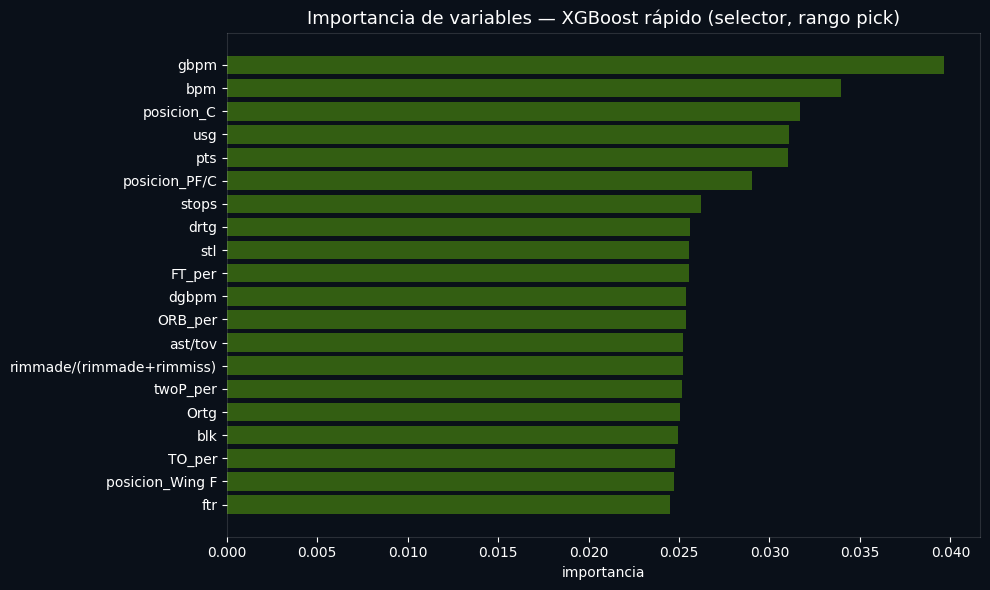

In [56]:
# ── paso 1: XGBoost rápido sobre todos los features ──────────────────────────
xgb_selector = XGBClassifier(
    objective='multi:softmax',
    num_class=n_clases,
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=11,
    eval_metric='mlogloss'
)
pesos_selector = compute_sample_weight(class_weight='balanced', y=y_train)
xgb_selector.fit(X_train, y_train, sample_weight=pesos_selector)

importancias_sel = pd.Series(
    xgb_selector.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(f"Features totales: {len(importancias_sel)}")
print("\nTop 20 por importancia:")
print(importancias_sel.head(20).round(4).to_string())

# visualización de importancias
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#0a1019')
ax.set_facecolor('#0a1019')
top20 = importancias_sel.head(20)
ax.barh(top20.index[::-1], top20.values[::-1], color='#3B6D11', alpha=0.85)
ax.set_xlabel('importancia', color='white')
ax.set_title('Importancia de variables — XGBoost rápido (selector, rango pick)', color='white', fontsize=13)
ax.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_edgecolor('#ffffff22')
plt.tight_layout()
plt.show()

In [57]:
# ── paso 2: candidatos por umbral acumulado y por número fijo ────────────────
importancia_norm = importancias_sel / importancias_sel.sum()
importancia_acum = importancia_norm.cumsum()

candidatos = {}

# umbral acumulado: variables que explican el X% de la importancia total
for umbral in [0.80, 0.90, 0.95]:
    vars_umbral = importancia_acum[importancia_acum <= umbral].index.tolist()
    # si quedan 0 (primera var ya supera el umbral), cogemos al menos 1
    if not vars_umbral:
        vars_umbral = [importancias_sel.index[0]]
    candidatos[f'acum_{int(umbral*100)}pct'] = vars_umbral

# número fijo
for n in [10, 15, 20]:
    candidatos[f'top{n}'] = importancias_sel.head(n).index.tolist()

print("Candidatos generados:")
for nombre, vars_ in candidatos.items():
    print(f"  {nombre}: {len(vars_)} variables")

Candidatos generados:
  acum_80pct: 30 variables
  acum_90pct: 35 variables
  acum_95pct: 38 variables
  top10: 10 variables
  top15: 15 variables
  top20: 20 variables


In [58]:
# ── paso 3: CV rápida (3 folds) para cada candidato ─────────────────────────
# nota: no pasamos sample_weight aquí — cross_val_score no lo admite directamente
# en versiones recientes de sklearn. para selección de features no hace falta:
# el desbalanceo afecta igual a todos los candidatos, la comparación sigue siendo válida.
cv3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=11)

xgb_cv = XGBClassifier(
    objective='multi:softmax',
    num_class=n_clases,
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=11,
    eval_metric='mlogloss'
)

resultados_sel = {}
for nombre, vars_ in candidatos.items():
    scores = cross_val_score(
        xgb_cv,
        X_train[vars_], y_train,
        scoring='f1_macro',
        cv=cv3,
        n_jobs=-1
    )
    resultados_sel[nombre] = {'vars': vars_, 'f1_mean': scores.mean(), 'f1_std': scores.std()}
    print(f"  {nombre:15s} ({len(vars_):2d} vars) → F1 macro: {scores.mean():.4f} ± {scores.std():.4f}")

# también evalúo todas las variables como referencia
scores_all = cross_val_score(
    xgb_cv, X_train, y_train,
    scoring='f1_macro', cv=cv3, n_jobs=-1
)
print(f"  {'todas':15s} ({X_train.shape[1]:2d} vars) → F1 macro: {scores_all.mean():.4f} ± {scores_all.std():.4f} (referencia)")

  acum_80pct      (30 vars) → F1 macro: 0.2479 ± 0.0083
  acum_90pct      (35 vars) → F1 macro: 0.2304 ± 0.0144
  acum_95pct      (38 vars) → F1 macro: 0.2558 ± 0.0130
  top10           (10 vars) → F1 macro: 0.2395 ± 0.0176
  top15           (15 vars) → F1 macro: 0.2323 ± 0.0128
  top20           (20 vars) → F1 macro: 0.2511 ± 0.0064
  todas           (43 vars) → F1 macro: 0.2517 ± 0.0206 (referencia)


In [59]:
# ── paso 4: elijo el mejor candidato y redefino X_train / X_test ─────────────
mejor_candidato = max(resultados_sel, key=lambda k: resultados_sel[k]['f1_mean'])
vars_seleccionadas = resultados_sel[mejor_candidato]['vars']

print(f"Candidato elegido: {mejor_candidato}")
print(f"Variables seleccionadas ({len(vars_seleccionadas)}): {vars_seleccionadas}")
print(f"F1 macro CV: {resultados_sel[mejor_candidato]['f1_mean']:.4f}")

# redefino X_train y X_test — el resto del notebook hereda este subconjunto
X_train = X_train[vars_seleccionadas]
X_test  = X_test[vars_seleccionadas]

print(f"\nX_train redefinido: {X_train.shape}")
print(f"X_test  redefinido: {X_test.shape}")

Candidato elegido: acum_95pct
Variables seleccionadas (38): ['gbpm', 'bpm', 'posicion_C', 'usg', 'pts', 'posicion_PF/C', 'stops', 'drtg', 'stl', 'FT_per', 'dgbpm', 'ORB_per', 'ast/tov', 'rimmade/(rimmade+rimmiss)', 'twoP_per', 'Ortg', 'blk', 'TO_per', 'posicion_Wing F', 'ftr', 'dbpm', 'stl_per', 'eFG', 'ogbpm', 'TP_per', 'Min_per', 'treb', 'altura_cm', 'TS_per', 'posicion_Pure PG', 'mp', 'midmade/(midmade+midmiss)', 'obpm', 'blk_per', 'GP', 'DRB_per', 'posicion_Wing G', 'AST_per']
F1 macro CV: 0.2558

X_train redefinido: (1802, 38)
X_test  redefinido: (319, 38)


## Estrategia 1 — RandomizedSearchCV sobre XGBoost

Con 7 clases tan desbalanceadas la búsqueda aleatoria puede ayudar a encontrar combinaciones de `max_depth` y `learning_rate` que regularicen el modelo sin colapsar en ND siempre.

Usamos `f1_macro` como métrica de scoring para penalizar igual todos los rangos.

In [60]:
pesos_train = compute_sample_weight(class_weight='balanced', y=y_train)

param_dist = {
    'n_estimators':     [100, 200, 300, 400],
    'max_depth':        [3, 4, 5, 6],
    'learning_rate':    [0.01, 0.05, 0.1, 0.15],
    'subsample':        [0.6, 0.7, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 1.0],
    'min_child_weight': [1, 3, 5, 7],
    'gamma':            [0, 0.1, 0.2, 0.5],
    'reg_alpha':        [0, 0.1, 0.5, 1.0],   # regularización L1
    'reg_lambda':       [1, 1.5, 2.0]          # regularización L2
}

xgb_base = XGBClassifier(
    objective='multi:softmax',
    num_class=n_clases,
    random_state=11,
    eval_metric='mlogloss'
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=11)

rnd_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=50,
    scoring='f1_macro',
    cv=cv,
    random_state=11,
    n_jobs=-1,
    verbose=1
)

rnd_search.fit(X_train, y_train, sample_weight=pesos_train)

print("\nMejores hiperparámetros:")
for k, v in rnd_search.best_params_.items():
    print(f"  {k}: {v}")
print(f"\nMejor F1 macro en CV: {rnd_search.best_score_:.4f}")


Fitting 5 folds for each of 50 candidates, totalling 250 fits

Mejores hiperparámetros:
  subsample: 0.6
  reg_lambda: 2.0
  reg_alpha: 0.5
  n_estimators: 100
  min_child_weight: 7
  max_depth: 3
  learning_rate: 0.05
  gamma: 0.1
  colsample_bytree: 1.0

Mejor F1 macro en CV: 0.2563


In [61]:
mejor_xgb = rnd_search.best_estimator_
y_pred_rxgb = mejor_xgb.predict(X_test)

print("=== XGBoost + RandomizedSearch ===")
print(classification_report(y_test, y_pred_rxgb, target_names=le_target_eleccion.classes_))


=== XGBoost + RandomizedSearch ===
              precision    recall  f1-score   support

        1-10       0.14      0.25      0.18        16
       11-20       0.10      0.19      0.13        16
       21-30       0.00      0.00      0.00        16
       31-40       0.14      0.19      0.16        16
       41-50       0.05      0.07      0.06        15
       51-60       0.19      0.29      0.23        14
          ND       0.88      0.74      0.80       226

    accuracy                           0.57       319
   macro avg       0.22      0.25      0.22       319
weighted avg       0.66      0.57      0.61       319



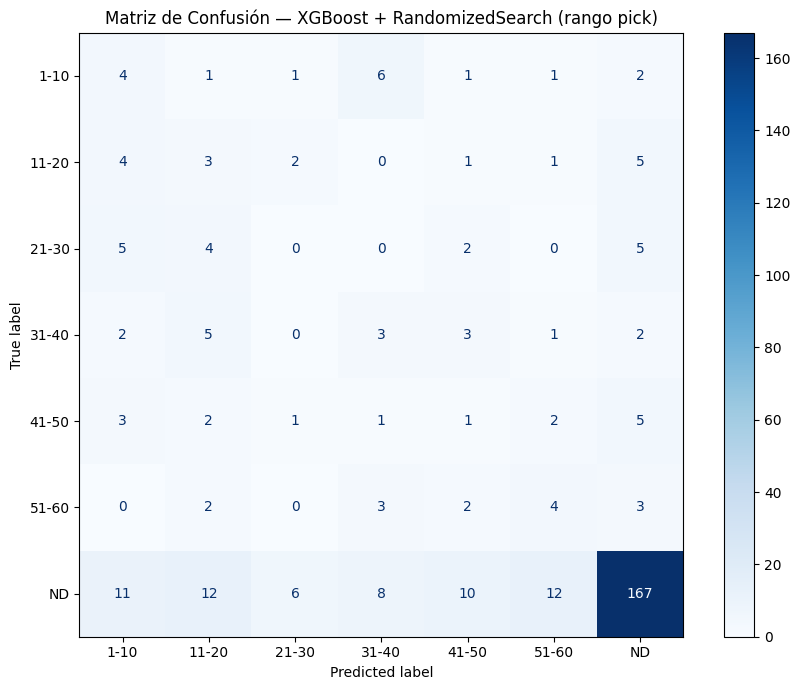

In [62]:
cm_rxgb = confusion_matrix(y_test, y_pred_rxgb)
disp = ConfusionMatrixDisplay(cm_rxgb, display_labels=le_target_eleccion.classes_)
fig, ax = plt.subplots(figsize=(9, 7))
disp.plot(cmap='Blues', ax=ax)
plt.title('Matriz de Confusión — XGBoost + RandomizedSearch (rango pick)')
plt.tight_layout()
plt.show()


## Estrategia 1b — GridSearch afinado sobre los mejores parámetros

El RandomizedSearch exploró 50 combinaciones aleatorias. Ahora tomamos los mejores valores encontrados y construimos una rejilla estrecha alrededor de cada uno: afinar con precisión quirúrgica en vez de disparar al azar.

Con 7 clases desbalanceadas la mejora puede ser modesta, pero vale la pena agotar la búsqueda exhaustiva antes de pasar a otros modelos.

In [63]:
# recupero los mejores parámetros del RandomizedSearch
best = rnd_search.best_params_
print("Punto de partida (mejores parámetros del RandomizedSearch):")
for k, v in best.items():
    print(f"  {k}: {v}")

def vecinos(val, opciones):
    """devuelve hasta 3 valores: el encontrado y sus vecinos en la lista de opciones"""
    if val not in opciones:
        opciones = sorted(opciones + [val])
    idx = opciones.index(val)
    return sorted(set(opciones[max(0, idx-1): idx+2]))

param_grid = {
    'n_estimators':     vecinos(best['n_estimators'],   [100, 200, 300, 400]),
    'max_depth':        vecinos(best['max_depth'],       [3, 4, 5, 6]),
    'learning_rate':    vecinos(best['learning_rate'],   [0.01, 0.05, 0.1, 0.15]),
    'subsample':        [best['subsample']],
    'colsample_bytree': [best['colsample_bytree']],
    'min_child_weight': vecinos(best['min_child_weight'],[1, 3, 5, 7]),
    'gamma':            vecinos(best['gamma'],           [0, 0.1, 0.2, 0.5]),
    'reg_alpha':        [best['reg_alpha']],
    'reg_lambda':       [best['reg_lambda']],
}

n_combinaciones = 1
for v in param_grid.values():
    n_combinaciones *= len(v)
print(f"\nCombinaciones a evaluar: {n_combinaciones}")

from sklearn.model_selection import GridSearchCV

xgb_grid_base = XGBClassifier(
    objective='multi:softmax',
    num_class=n_clases,
    random_state=11,
    eval_metric='mlogloss'
)

grid_search = GridSearchCV(
    estimator=xgb_grid_base,
    param_grid=param_grid,
    scoring='f1_macro',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=11),
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train, sample_weight=pesos_train)

print("\nMejores hiperparámetros (GridSearch):")
for k, v in grid_search.best_params_.items():
    print(f"  {k}: {v}")
print(f"\nMejor F1 macro en CV (GridSearch):     {grid_search.best_score_:.4f}")
print(f"Mejor F1 macro en CV (RandomizedSearch): {rnd_search.best_score_:.4f}")
print(f"Mejora:                                  {grid_search.best_score_ - rnd_search.best_score_:+.4f}")

Punto de partida (mejores parámetros del RandomizedSearch):
  subsample: 0.6
  reg_lambda: 2.0
  reg_alpha: 0.5
  n_estimators: 100
  min_child_weight: 7
  max_depth: 3
  learning_rate: 0.05
  gamma: 0.1
  colsample_bytree: 1.0

Combinaciones a evaluar: 72
Fitting 5 folds for each of 72 candidates, totalling 360 fits

Mejores hiperparámetros (GridSearch):
  colsample_bytree: 1.0
  gamma: 0.2
  learning_rate: 0.05
  max_depth: 4
  min_child_weight: 7
  n_estimators: 100
  reg_alpha: 0.5
  reg_lambda: 2.0
  subsample: 0.6

Mejor F1 macro en CV (GridSearch):     0.2702
Mejor F1 macro en CV (RandomizedSearch): 0.2563
Mejora:                                  +0.0139


In [64]:
# evalúo el modelo afinado en test
xgb_grid = grid_search.best_estimator_
y_pred_grid = xgb_grid.predict(X_test)

print("=== XGBoost GridSearch afinado ===")
print(classification_report(y_test, y_pred_grid, target_names=le_target_eleccion.classes_))

=== XGBoost GridSearch afinado ===
              precision    recall  f1-score   support

        1-10       0.17      0.31      0.22        16
       11-20       0.04      0.06      0.05        16
       21-30       0.00      0.00      0.00        16
       31-40       0.05      0.06      0.05        16
       41-50       0.06      0.07      0.06        15
       51-60       0.28      0.36      0.31        14
          ND       0.90      0.78      0.83       226

    accuracy                           0.59       319
   macro avg       0.21      0.23      0.22       319
weighted avg       0.66      0.59      0.62       319



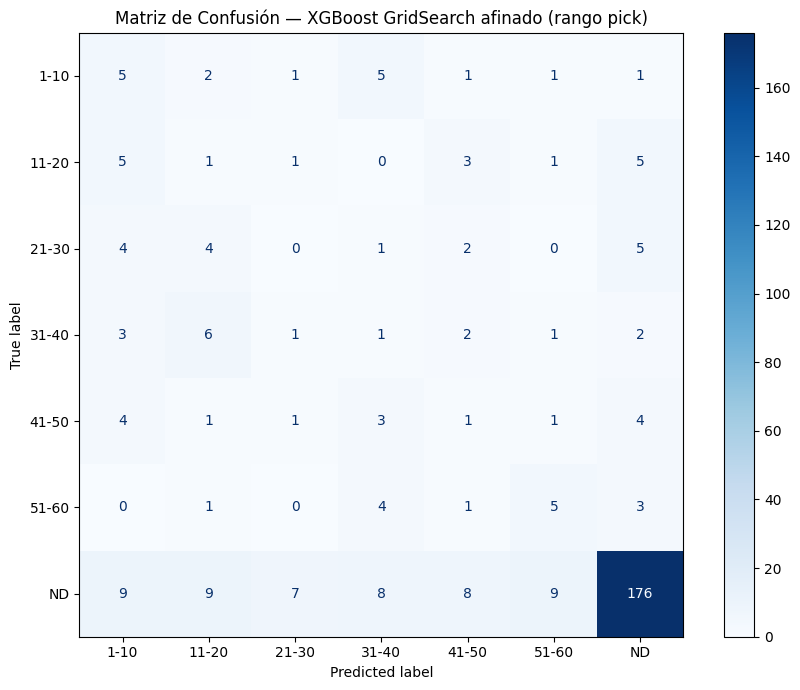

In [65]:
cm_grid = confusion_matrix(y_test, y_pred_grid)
disp_grid = ConfusionMatrixDisplay(cm_grid, display_labels=le_target_eleccion.classes_)
fig, ax = plt.subplots(figsize=(9, 7))
disp_grid.plot(cmap='Blues', ax=ax)
plt.title('Matriz de Confusión — XGBoost GridSearch afinado (rango pick)')
plt.tight_layout()
plt.show()

## Estrategia 2 — LightGBM con parámetros ajustados

LightGBM tiene la ventaja de `num_leaves` (controla la complejidad del árbol de forma más fina que `max_depth`) y `min_data_in_leaf` (regulariza los nodos hoja, muy útil cuando hay rangos con solo 14-16 muestras en test).

In [66]:
lgbm_model = lgb.LGBMClassifier(
    objective='multiclass',
    num_class=n_clases,
    n_estimators=400,
    max_depth=6,
    num_leaves=31,         # controla complejidad del árbol (< 2^max_depth para regularizar)
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=5,   # con clases pequeñas, bajo este valor para no perder hojas
    class_weight='balanced',
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=11,
    verbose=-1
)

lgbm_model.fit(X_train, y_train)
y_pred_lgbm = lgbm_model.predict(X_test)

print("=== LightGBM balanceado ===")
print(classification_report(y_test, y_pred_lgbm, target_names=le_target_eleccion.classes_))


=== LightGBM balanceado ===
              precision    recall  f1-score   support

        1-10       0.20      0.25      0.22        16
       11-20       0.00      0.00      0.00        16
       21-30       0.00      0.00      0.00        16
       31-40       0.10      0.06      0.08        16
       41-50       0.00      0.00      0.00        15
       51-60       0.50      0.14      0.22        14
          ND       0.82      0.96      0.88       226

    accuracy                           0.70       319
   macro avg       0.23      0.20      0.20       319
weighted avg       0.62      0.70      0.65       319



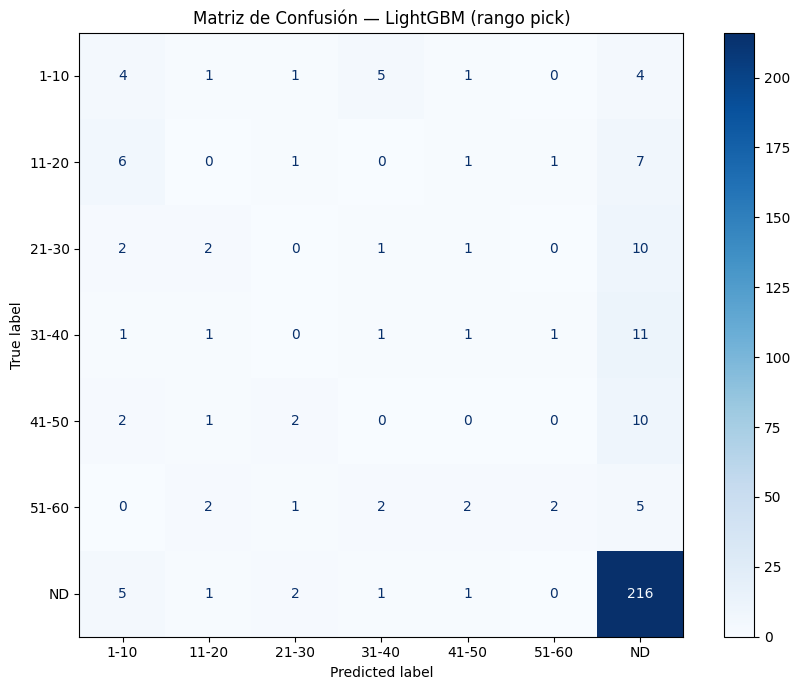

In [67]:
cm_lgbm = confusion_matrix(y_test, y_pred_lgbm)
disp_lgbm = ConfusionMatrixDisplay(cm_lgbm, display_labels=le_target_eleccion.classes_)
fig, ax = plt.subplots(figsize=(9, 7))
disp_lgbm.plot(cmap='Blues', ax=ax)
plt.title('Matriz de Confusión — LightGBM (rango pick)')
plt.tight_layout()
plt.show()


## Estrategia 3 — Reducción de clases (3 → 7)

El desbalanceo es tan extremo que los rangos individuales son casi imposibles de aprender. Una estrategia es trabajar con 3 clases primero (ND / R1 / R2), como en el modelo de ronda, y luego aplicar un segundo clasificador solo sobre los jugadores predichos como drafteados.

Aquí construimos ese **segundo nivel**: dado que el modelo de ronda ya clasifica bien ND, entrenamos un modelo solo sobre los ~600 jugadores drafteados para predecir si son R1 (1-30) o R2 (31-60). Es un problema binario mucho más manejable.

In [68]:
# filtro solo los jugadores drafteados del dataset completo
ncaa_drafteados = ncaa[ncaa['ronda'] != 'ND'].copy()

print(f"Jugadores drafteados en el dataset: {len(ncaa_drafteados)}")
print("Distribución por rango:")
print(ncaa_drafteados['rango_pick'].value_counts())


Jugadores drafteados en el dataset: 621
Distribución por rango:
rango_pick
1-10     108
21-30    108
11-20    106
31-40    104
41-50    102
51-60     93
Name: count, dtype: int64


In [69]:
# preparo X e y solo para drafteados
X_draft = ncaa_drafteados.drop(columns=['ronda', 'rango_pick'])
X_draft = pd.get_dummies(X_draft, columns=['posicion'], drop_first=False)

le_rango_draft = LabelEncoder()
y_draft_enc = le_rango_draft.fit_transform(ncaa_drafteados['rango_pick'])

print("Clases rango (solo drafteados):", le_rango_draft.classes_)
print("Distribución:", pd.Series(y_draft_enc).value_counts(normalize=True).round(3).to_dict())


Clases rango (solo drafteados): ['1-10' '11-20' '21-30' '31-40' '41-50' '51-60']
Distribución: {0: 0.174, 2: 0.174, 1: 0.171, 3: 0.167, 4: 0.164, 5: 0.15}


In [70]:
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_draft, y_draft_enc,
    test_size=0.15,
    random_state=11,
    stratify=y_draft_enc
)

print(f"Train drafteados: {X_train_d.shape} | Test: {X_test_d.shape}")


Train drafteados: (527, 43) | Test: (94, 43)


In [71]:
# LightGBM entrenado solo sobre drafteados — problema de 6 clases en vez de 7
# el desbalanceo desaparece porque quitamos el 70% de ND
lgbm_draft_only = lgb.LGBMClassifier(
    objective='multiclass',
    num_class=len(le_rango_draft.classes_),
    n_estimators=300,
    max_depth=5,
    num_leaves=20,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=5,
    class_weight='balanced',
    random_state=11,
    verbose=-1
)

lgbm_draft_only.fit(X_train_d, y_train_d)
y_pred_do = lgbm_draft_only.predict(X_test_d)

print("=== LightGBM solo sobre jugadores drafteados ===")
print(classification_report(y_test_d, y_pred_do, target_names=le_rango_draft.classes_))


=== LightGBM solo sobre jugadores drafteados ===
              precision    recall  f1-score   support

        1-10       0.24      0.25      0.24        16
       11-20       0.29      0.38      0.32        16
       21-30       0.25      0.12      0.17        16
       31-40       0.09      0.12      0.10        16
       41-50       0.25      0.19      0.21        16
       51-60       0.23      0.21      0.22        14

    accuracy                           0.21        94
   macro avg       0.22      0.21      0.21        94
weighted avg       0.22      0.21      0.21        94



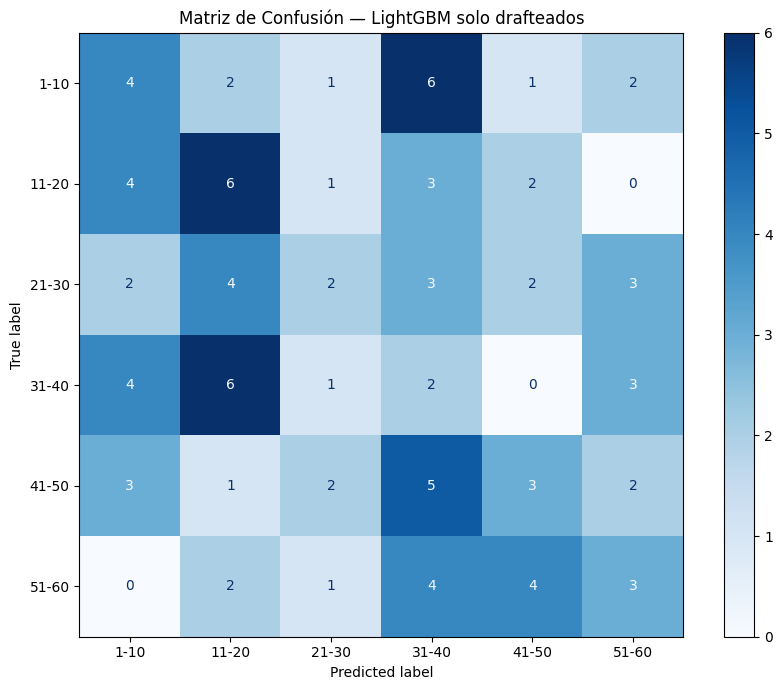

In [72]:
cm_do = confusion_matrix(y_test_d, y_pred_do)
disp_do = ConfusionMatrixDisplay(cm_do, display_labels=le_rango_draft.classes_)
fig, ax = plt.subplots(figsize=(9, 7))
disp_do.plot(cmap='Blues', ax=ax)
plt.title('Matriz de Confusión — LightGBM solo drafteados')
plt.tight_layout()
plt.show()


## Estrategia 4 — Feature importance y top variables

Igual que en el modelo de ronda, usamos las variables más importantes del XGBoost optimizado para entrenar un LightGBM más limpio.

> **Nota:** aquí la importancia se calcula sobre el XGBoost optimizado (post RandomizedSearch) para ver si el ranking cambia respecto al selector inicial.

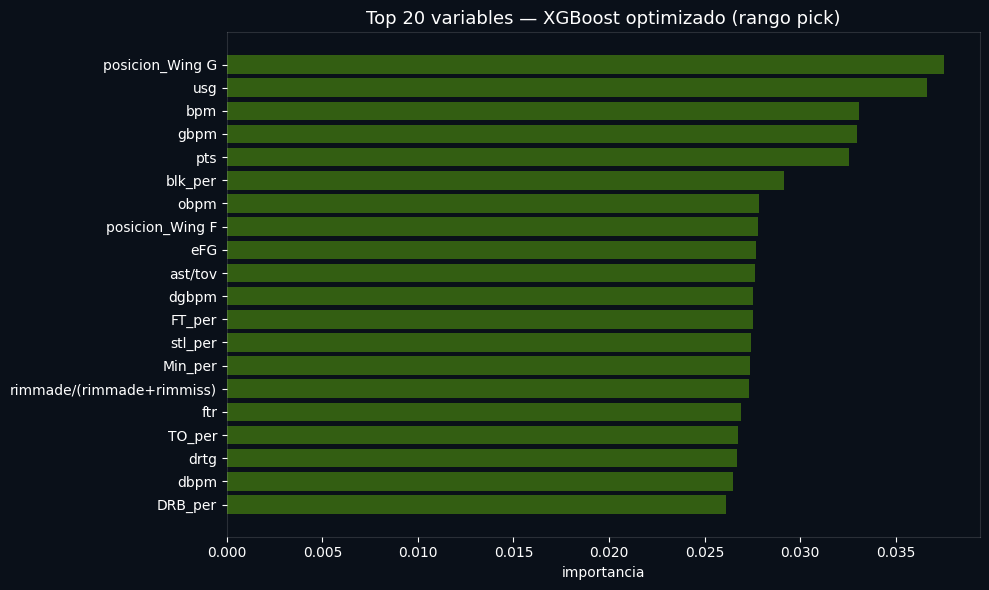

In [73]:
importancias = pd.Series(
    mejor_xgb.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#0a1019')
ax.set_facecolor('#0a1019')
top20 = importancias.head(20)
ax.barh(top20.index[::-1], top20.values[::-1], color='#3B6D11', alpha=0.85)
ax.set_xlabel('importancia', color='white')
ax.set_title('Top 20 variables — XGBoost optimizado (rango pick)', color='white', fontsize=13)
ax.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_edgecolor('#ffffff22')
plt.tight_layout()
plt.show()


In [74]:
top15_vars = importancias.head(15).index.tolist()
print("Top 15 variables seleccionadas:")
for v in top15_vars: print(f"  - {v}")

X_train_top = X_train[top15_vars]
X_test_top  = X_test[top15_vars]

lgbm_top = lgb.LGBMClassifier(
    objective='multiclass',
    num_class=n_clases,
    n_estimators=400,
    max_depth=6,
    num_leaves=25,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=5,
    class_weight='balanced',
    random_state=11,
    verbose=-1
)

lgbm_top.fit(X_train_top, y_train)
y_pred_top = lgbm_top.predict(X_test_top)

print("\n=== LightGBM top 15 variables ===")
print(classification_report(y_test, y_pred_top, target_names=le_target_eleccion.classes_))


Top 15 variables seleccionadas:
  - posicion_Wing G
  - usg
  - bpm
  - gbpm
  - pts
  - blk_per
  - obpm
  - posicion_Wing F
  - eFG
  - ast/tov
  - dgbpm
  - FT_per
  - stl_per
  - Min_per
  - rimmade/(rimmade+rimmiss)

=== LightGBM top 15 variables ===
              precision    recall  f1-score   support

        1-10       0.11      0.12      0.11        16
       11-20       0.29      0.12      0.17        16
       21-30       0.00      0.00      0.00        16
       31-40       0.11      0.06      0.08        16
       41-50       0.00      0.00      0.00        15
       51-60       0.33      0.14      0.20        14
          ND       0.79      0.94      0.86       226

    accuracy                           0.69       319
   macro avg       0.23      0.20      0.20       319
weighted avg       0.60      0.69      0.64       319



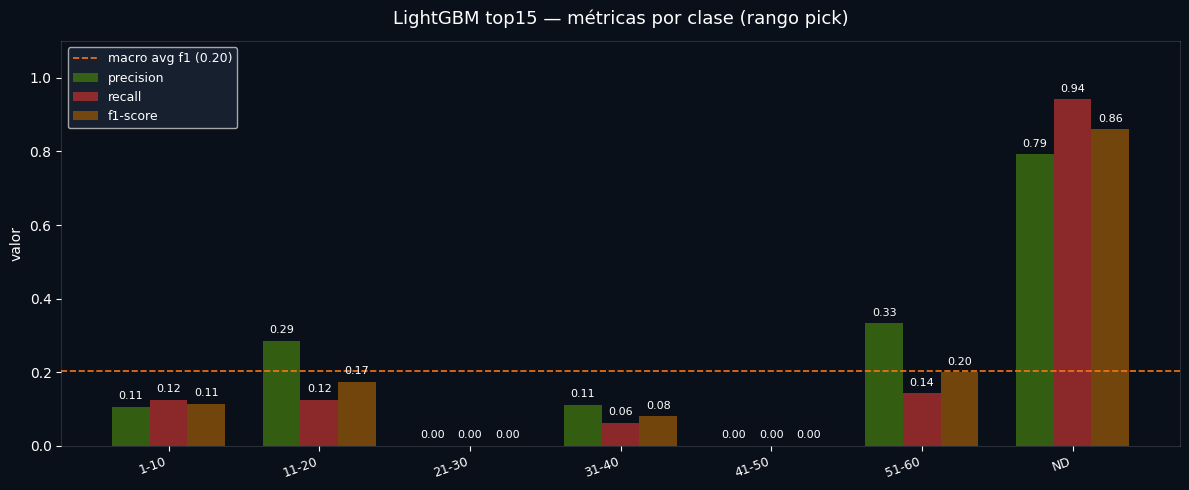

In [75]:
# visualización LightGBM top15 (rango pick)
report_top = classification_report(y_test, y_pred_top, target_names=le_target_eleccion.classes_, output_dict=True)
clases_e = le_target_eleccion.classes_.tolist()

x_e   = np.arange(len(clases_e))
ancho_e = 0.25
colores_e = ['#3B6D11', '#A32D2D', '#854F0B']

precision_t = [report_top[c]['precision'] for c in clases_e]
recall_t    = [report_top[c]['recall']    for c in clases_e]
f1_t        = [report_top[c]['f1-score']  for c in clases_e]
metricas_t  = {'precision': precision_t, 'recall': recall_t, 'f1-score': f1_t}

fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor('#0a1019')
ax.set_facecolor('#0a1019')
for i, (nombre, valores) in enumerate(metricas_t.items()):
    barras = ax.bar(x_e + i * ancho_e, valores, ancho_e, label=nombre, color=colores_e[i], alpha=0.85)
    for barra in barras:
        alto = barra.get_height()
        ax.text(barra.get_x() + barra.get_width() / 2, alto + 0.015,
                f'{alto:.2f}', ha='center', va='bottom', fontsize=8, color='white')
macro_f1_t = report_top['macro avg']['f1-score']
ax.axhline(y=macro_f1_t, color='#f97316', linestyle='--', linewidth=1.2, label=f'macro avg f1 ({macro_f1_t:.2f})')
ax.set_xticks(x_e + ancho_e)
ax.set_xticklabels(clases_e, color='white', fontsize=9, rotation=20, ha='right')
ax.set_ylim(0, 1.1)
ax.set_ylabel('valor', color='white')
ax.set_title('LightGBM top15 — métricas por clase (rango pick)', color='white', fontsize=13, pad=12)
ax.tick_params(colors='white')
ax.legend(facecolor='#1a2535', labelcolor='white', fontsize=9)
for spine in ax.spines.values():
    spine.set_edgecolor('#ffffff22')
plt.tight_layout()
plt.show()

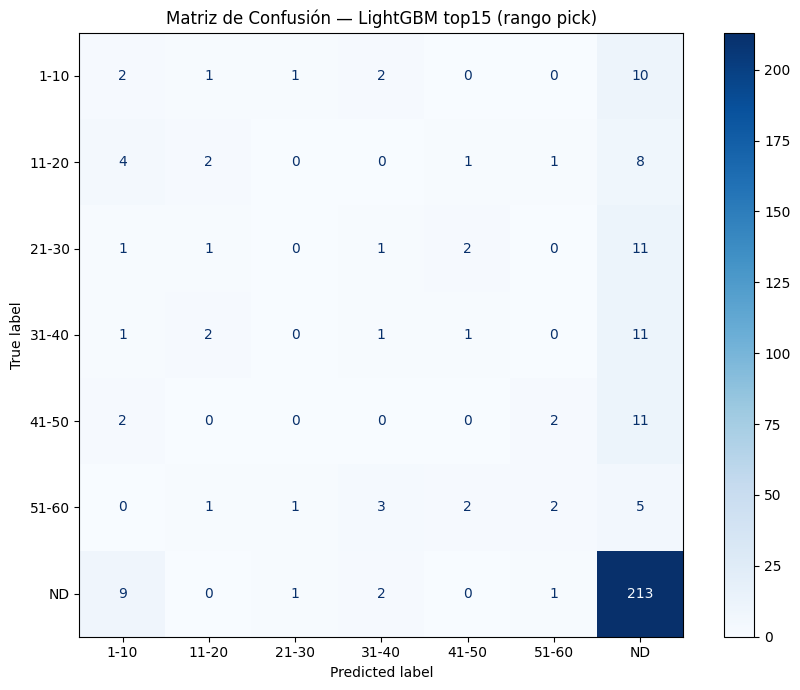

In [76]:
cm_top = confusion_matrix(y_test, y_pred_top)
disp_top = ConfusionMatrixDisplay(cm_top, display_labels=le_target_eleccion.classes_)
fig, ax = plt.subplots(figsize=(9, 7))
disp_top.plot(cmap='Blues', ax=ax)
plt.title('Matriz de Confusión — LightGBM top15 (rango pick)')
plt.tight_layout()
plt.show()

## Estrategia 5 — Random Forest con pesos balanceados

Mismo planteamiento que en el modelo de ronda pero con 7 clases. Random Forest suele ser más robusto que SVM o Regresión Logística ante desbalanceo extremo gracias al bagging — cada árbol ve una muestra diferente del dataset.

In [77]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=3,    # bajo para no perder las clases minoritarias
    class_weight='balanced',
    random_state=11,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("=== Random Forest balanceado ===")
print(classification_report(y_test, y_pred_rf, target_names=le_target_eleccion.classes_))


=== Random Forest balanceado ===
              precision    recall  f1-score   support

        1-10       0.18      0.38      0.24        16
       11-20       0.08      0.06      0.07        16
       21-30       0.00      0.00      0.00        16
       31-40       0.12      0.19      0.15        16
       41-50       0.12      0.13      0.12        15
       51-60       0.25      0.21      0.23        14
          ND       0.86      0.81      0.83       226

    accuracy                           0.62       319
   macro avg       0.23      0.25      0.24       319
weighted avg       0.64      0.62      0.63       319



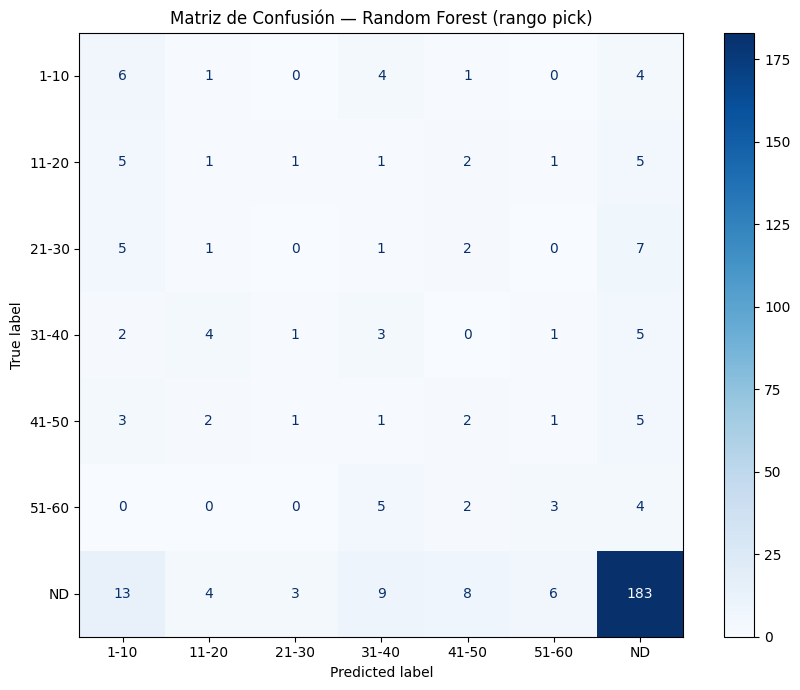

In [78]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(cm_rf, display_labels=le_target_eleccion.classes_)
fig, ax = plt.subplots(figsize=(9, 7))
disp_rf.plot(cmap='Blues', ax=ax)
plt.title('Matriz de Confusión — Random Forest (rango pick)')
plt.tight_layout()
plt.show()


## Estrategia 6 — SVM con kernel RBF

SVM es el modelo más costoso computacionalmente con 7 clases (usa One vs One internamente: 21 clasificadores binarios). Con datasets de ~2000 filas es manejable. El pipeline incluye StandardScaler obligatorio.

In [79]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(
        kernel='rbf',
        C=1.0,
        gamma='scale',
        class_weight='balanced',
        probability=True,
        random_state=11
    ))
])

svm_pipeline.fit(X_train, y_train)
y_pred_svm = svm_pipeline.predict(X_test)

print("=== SVM kernel RBF ===")
print(classification_report(y_test, y_pred_svm, target_names=le_target_eleccion.classes_))


=== SVM kernel RBF ===
              precision    recall  f1-score   support

        1-10       0.12      0.19      0.14        16
       11-20       0.07      0.12      0.09        16
       21-30       0.05      0.06      0.05        16
       31-40       0.10      0.12      0.11        16
       41-50       0.06      0.13      0.08        15
       51-60       0.11      0.21      0.15        14
          ND       0.89      0.64      0.74       226

    accuracy                           0.49       319
   macro avg       0.20      0.21      0.20       319
weighted avg       0.66      0.49      0.56       319



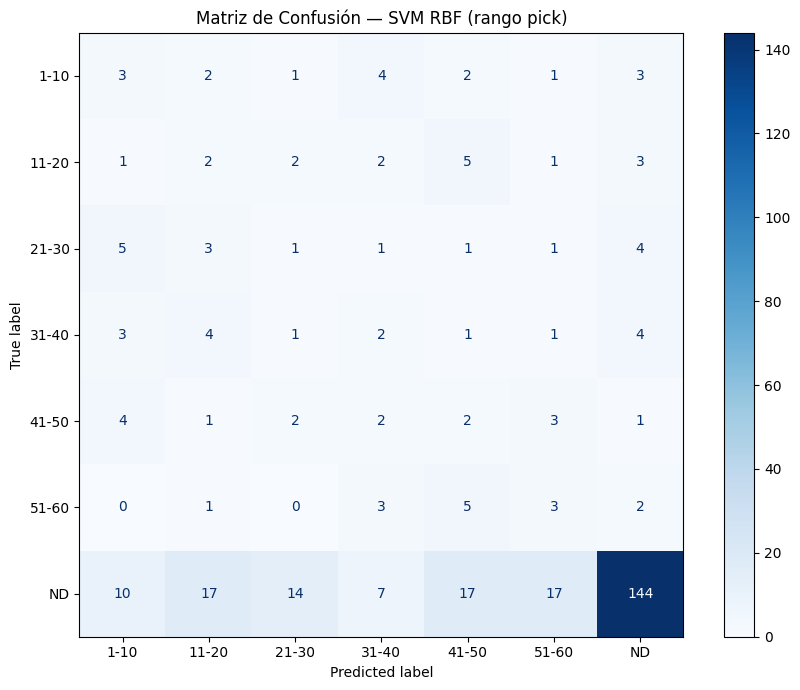

In [80]:
cm_svm = confusion_matrix(y_test, y_pred_svm)
disp_svm = ConfusionMatrixDisplay(cm_svm, display_labels=le_target_eleccion.classes_)
fig, ax = plt.subplots(figsize=(9, 7))
disp_svm.plot(cmap='Blues', ax=ax)
plt.title('Matriz de Confusión — SVM RBF (rango pick)')
plt.tight_layout()
plt.show()


## Estrategia 7 — Regresión Logística

Baseline lineal. Con 7 clases muy solapadas esperamos que sea el peor modelo, pero sirve para confirmar que la no-linealidad de XGBoost y LightGBM aporta valor real.

In [81]:
from sklearn.linear_model import LogisticRegression

lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(
        solver='lbfgs',
        max_iter=2000,        # más iteraciones por el número de clases
        class_weight='balanced',
        random_state=11
    ))
])

lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)

print("=== Regresión Logística ===")
print(classification_report(y_test, y_pred_lr, target_names=le_target_eleccion.classes_))

=== Regresión Logística ===
              precision    recall  f1-score   support

        1-10       0.22      0.44      0.29        16
       11-20       0.07      0.12      0.09        16
       21-30       0.05      0.06      0.06        16
       31-40       0.00      0.00      0.00        16
       41-50       0.06      0.13      0.08        15
       51-60       0.13      0.29      0.18        14
          ND       0.91      0.61      0.73       226

    accuracy                           0.48       319
   macro avg       0.20      0.24      0.20       319
weighted avg       0.67      0.48      0.55       319



## Comparativa final — todos los modelos

In [82]:
# reconstruyo base para comparar
modelo_base_ref = XGBClassifier(
    objective='multi:softmax', num_class=n_clases,
    n_estimators=100, max_depth=4, learning_rate=0.1,
    random_state=11, eval_metric='mlogloss'
)
pesos_base = compute_sample_weight(class_weight='balanced', y=y_train)
modelo_base_ref.fit(X_train, y_train, sample_weight=pesos_base)
y_pred_base = modelo_base_ref.predict(X_test)

# nota: LGBM drafteados se excluye de esta comparativa porque se evaluó
# sobre y_test_d (solo jugadores drafteados), no sobre y_test completo
modelos_todos = [
    ('Base XGB',         y_pred_base),
    ('XGB RndSearch',    y_pred_rxgb),
    ('XGB GridSearch',   y_pred_grid),
    ('LightGBM',         y_pred_lgbm),
    ('LGBM top15',       y_pred_top),
    ('Random Forest',    y_pred_rf),
    ('SVM RBF',          y_pred_svm),
    ('Log. Regression',  y_pred_lr),
]

rows = []
for nombre, preds in modelos_todos:
    rep = classification_report(y_test, preds, target_names=le_target_eleccion.classes_, output_dict=True)
    rows.append({
        'modelo':   nombre,
        'macro_f1': round(rep['macro avg']['f1-score'], 4),
        'f1_ND':    round(rep['ND']['f1-score'], 4),
        'f1_1-10':  round(rep['1-10']['f1-score'], 4),
        'f1_51-60': round(rep['51-60']['f1-score'], 4),
    })

df_todos = pd.DataFrame(rows).sort_values('macro_f1', ascending=False)
print(df_todos.to_string(index=False))

         modelo  macro_f1  f1_ND  f1_1-10  f1_51-60
  Random Forest    0.2355 0.8337   0.2400    0.2308
       Base XGB    0.2277 0.8337   0.2000    0.2424
  XGB RndSearch    0.2234 0.8048   0.1778    0.2286
 XGB GridSearch    0.2182 0.8341   0.2174    0.3125
     LGBM top15    0.2041 0.8606   0.1143    0.2000
Log. Regression    0.2029 0.7302   0.2917    0.1778
       LightGBM    0.2007 0.8834   0.2222    0.2222
        SVM RBF    0.1951 0.7442   0.1429    0.1463


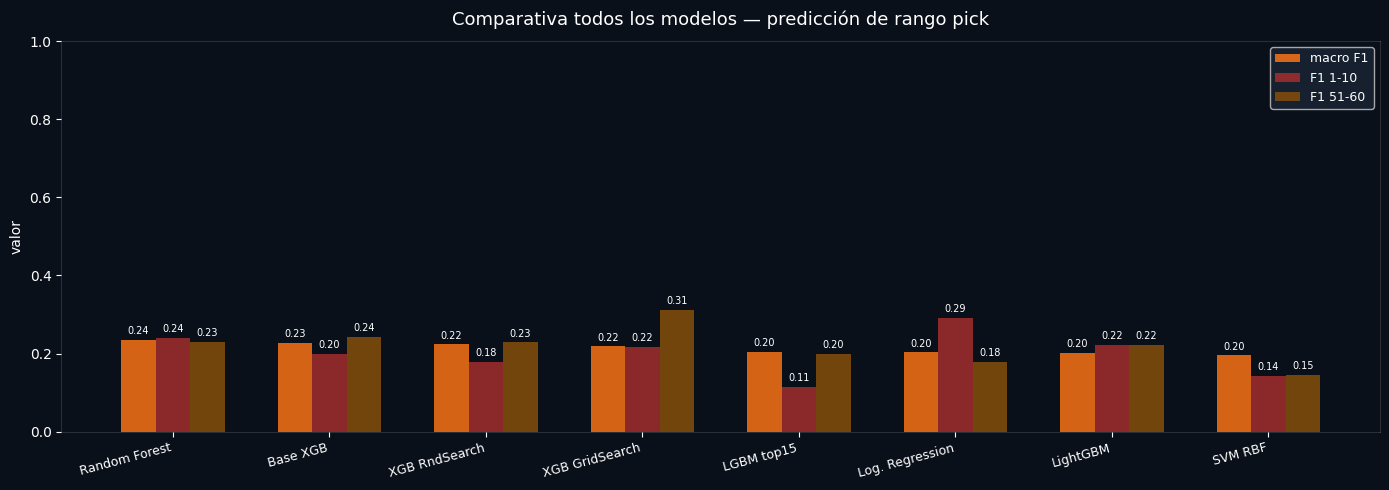

In [83]:
fig, ax = plt.subplots(figsize=(14, 5))
fig.patch.set_facecolor('#0a1019')
ax.set_facecolor('#0a1019')

nombres = df_todos['modelo'].tolist()
x_pos = np.arange(len(nombres))
cols_m    = ['macro_f1', 'f1_1-10', 'f1_51-60']
colores_c = ['#f97316', '#A32D2D', '#854F0B']
etiq_c    = ['macro F1', 'F1 1-10', 'F1 51-60']
ancho_c   = 0.22

for i, (col, color, etiq) in enumerate(zip(cols_m, colores_c, etiq_c)):
    vals = df_todos[col].tolist()
    barras = ax.bar(x_pos + i * ancho_c, vals, ancho_c, label=etiq, color=color, alpha=0.85)
    for b in barras:
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.01,
                f'{b.get_height():.2f}', ha='center', va='bottom', fontsize=7, color='white')

ax.set_xticks(x_pos + ancho_c)
ax.set_xticklabels(nombres, color='white', fontsize=9, rotation=15, ha='right')
ax.set_ylim(0, 1.0)
ax.set_ylabel('valor', color='white')
ax.set_title('Comparativa todos los modelos — predicción de rango pick', color='white', fontsize=13, pad=12)
ax.tick_params(colors='white')
ax.legend(facecolor='#1a2535', labelcolor='white', fontsize=9)
for spine in ax.spines.values():
    spine.set_edgecolor('#ffffff22')
plt.tight_layout()
plt.show()


In [84]:
os.makedirs('../../pkl/modelos', exist_ok=True)
os.makedirs('../../pkl/preprocesado', exist_ok=True)

joblib.dump(mejor_xgb,        '../../pkl/modelos/xgb_rango_randsearch.pkl')
joblib.dump(xgb_grid,         '../../pkl/modelos/xgb_rango_gridsearch.pkl')
joblib.dump(lgbm_model,       '../../pkl/modelos/lgbm_rango_balanceado.pkl')
joblib.dump(lgbm_draft_only,  '../../pkl/modelos/lgbm_rango_solo_drafteados.pkl')
joblib.dump(lgbm_top,         '../../pkl/modelos/lgbm_rango_top15.pkl')
joblib.dump(rf_model,         '../../pkl/modelos/rf_rango.pkl')
joblib.dump(svm_pipeline,     '../../pkl/modelos/svm_rango.pkl')
joblib.dump(lr_pipeline,      '../../pkl/modelos/lr_rango.pkl')
joblib.dump(le_rango_draft,   '../../pkl/preprocesado/le_rango_draft_only.pkl')
joblib.dump(top15_vars,       '../../pkl/preprocesado/top15_vars_rango.pkl')

print("Modelos guardados")


Modelos guardados


## Modelo simplificado para la app — solo stats básicas

Entreno un Random Forest usando únicamente variables interpretables (puntos, rebotes, asistencias, robos, tapones, eFG%, FT%, altura, minutos y partidos jugados) más el one-hot de posición.

Este modelo es el que alimenta la app Streamlit — permite introducir stats básicas sin necesidad de calcular métricas avanzadas como BPM o usage rate.

In [ ]:
# mismo conjunto de variables básicas para el modelo de rango
VARS_BASICAS = ['pts', 'treb', 'ast', 'stl', 'blk', 'eFG', 'FT_per', 'altura_cm', 'GP', 'mp']

ncaa_app = pd.read_csv('../../datos/procesados/ncaa_final.csv')
X_app    = ncaa_app.drop(columns=['ronda', 'rango_pick'])
X_app    = pd.get_dummies(X_app, columns=['posicion'], drop_first=False)
y_app    = le_target_eleccion.transform(ncaa_app['rango_pick'])

cols_pos = [c for c in X_app.columns if c.startswith('posicion_')]
VARS_APP_RANGO = VARS_BASICAS + cols_pos

X_app_final = X_app[VARS_APP_RANGO]

X_train_app, X_test_app, y_train_app, y_test_app = train_test_split(
    X_app_final, y_app,
    test_size=0.15, random_state=11, stratify=y_app
)

rf_app_rango = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=11,
    n_jobs=-1
)
rf_app_rango.fit(X_train_app, y_train_app)
y_pred_app = rf_app_rango.predict(X_test_app)

print("=== Random Forest — modelo app (stats básicas) ===")
print(classification_report(y_test_app, y_pred_app, target_names=le_target_eleccion.classes_))
print(f"Columnas del modelo: {VARS_APP_RANGO}")

In [ ]:
# guardo el modelo app de rango
joblib.dump(rf_app_rango,  '../../pkl/modelos/rf_app_rango.pkl')
joblib.dump(VARS_APP_RANGO, '../../pkl/preprocesado/vars_app_rango.pkl')
print("Modelo app rango guardado")
print(f"Variables: {VARS_APP_RANGO}")

## Elección del modelo final — predicción de rango de pick

Tras comparar ocho modelos, el modelo elegido para predecir el rango de elección en el draft es **Random Forest con pesos balanceados**.

### Resultados

| modelo | macro F1 | F1 ND | F1 1-10 | F1 51-60 |
|---|---|---|---|---|
| **Random Forest** | **0.2355** | **0.8337** | **0.2400** | **0.2308** |
| Base XGB | 0.2277 | 0.8337 | 0.2000 | 0.2424 |
| XGB RndSearch | 0.2234 | 0.8048 | 0.1778 | 0.2286 |
| XGB GridSearch | 0.2182 | 0.8341 | 0.2174 | 0.3125 |
| LGBM top15 | 0.2041 | 0.8606 | 0.1143 | 0.2000 |
| Log. Regression | 0.2029 | 0.7302 | 0.2917 | 0.1778 |
| LightGBM | 0.2007 | 0.8834 | 0.2222 | 0.2222 |
| SVM RBF | 0.1951 | 0.7442 | 0.1429 | 0.1463 |

### Por qué Random Forest

Random Forest obtiene el mejor macro F1 global (0.2355) y el mejor F1 en el rango 1-10 (0.2400), que es el más relevante para el proyecto: identificar correctamente a los jugadores con perfil de lotería.

### Contexto imprescindible: por qué los números son bajos

Un macro F1 de 0.23 parece malo, pero es el resultado esperable con este problema. Hay tres razones estructurales:

**1. Siete clases muy desbalanceadas.** El 70% de los jugadores son ND. Los rangos drafteados tienen entre 14 y 20 muestras en test cada uno — con tan pocas instancias, cualquier modelo tiene margen de mejora muy limitado.

**2. La frontera entre rangos es arbitraria.** La diferencia estadística entre el pick 10 y el pick 11, o entre el pick 30 y el pick 31, es prácticamente inexistente. El modelo no puede aprender lo que no existe en los datos.

**3. El draft no es puramente estadístico.** Necesidades de franquicia, lesiones, decisiones de agentes y preferencias de entrenadores son factores que ningún modelo puede capturar con datos de NCAA.

### Lo que el modelo sí hace bien

El F1 de ND se mantiene por encima de 0.83 en todos los modelos — el sistema distingue bien quién entra en el draft y quién no. La dificultad está en afinar el rango exacto una vez dentro, que es el problema más difícil del proyecto y el que refleja fielmente la incertidumbre real del día del draft.

### Modelo guardado

`rf_rango.pkl` — Random Forest balanceado, entrenado sobre el subconjunto de variables seleccionado automáticamente por importancia.

In [85]:
# ── predicción individual — rango de pick ────────────────────────────────────
X_test_original = ncaa.loc[X_test.index].copy()

print("Jugadores disponibles en test (índice | rango real):")
print(X_test_original['rango_pick'].to_string())

Jugadores disponibles en test (índice | rango real):
1615       ND
1044       ND
184     41-50
1259       ND
1359       ND
1848       ND
171      1-10
758        ND
1979       ND
861        ND
1057       ND
510     31-40
1269       ND
770        ND
2040       ND
1860       ND
325     21-30
1214       ND
371      1-10
1131       ND
1458       ND
1516       ND
573     11-20
237     21-30
774        ND
60      21-30
826        ND
1813       ND
372     41-50
820        ND
409     21-30
477     31-40
741        ND
1437       ND
536     51-60
1989       ND
1329       ND
495     51-60
1467       ND
1906       ND
1708       ND
1716       ND
1389       ND
1742       ND
1700       ND
1176       ND
825        ND
1474       ND
1745       ND
2011       ND
345     11-20
1274       ND
2081       ND
447     11-20
1096       ND
942        ND
628        ND
164     41-50
232     51-60
1525       ND
21      41-50
1812       ND
1008       ND
699        ND
1710       ND
2020       ND
387     51-60
715      

In [86]:
# cambia idx por cualquier índice de los de arriba
idx = 1804  # <-- modifica aquí

X_jugador    = X_test.loc[[idx]]
rango_pred   = le_target_eleccion.inverse_transform(rf_model.predict(X_jugador))[0]
rango_real   = ncaa.loc[idx, 'rango_pick']
probas       = rf_model.predict_proba(X_jugador)[0]

print(f"Índice:          {idx}")
print(f"Rango real:      {rango_real}")
print(f"Rango predicho:  {rango_pred}")
print(f"\nProbabilidades por rango:")
for clase, prob in zip(le_target_eleccion.classes_, probas):
    barra = '█' * int(prob * 30)
    print(f"  {clase:8s}  {barra} {prob:.2%}")

Índice:          1804
Rango real:      ND
Rango predicho:  ND

Probabilidades por rango:
  1-10      ██ 9.47%
  11-20     ███ 11.74%
  21-30     ███ 10.65%
  31-40     ████ 13.53%
  41-50     ████ 15.73%
  51-60     █████ 17.19%
  ND        ██████ 21.69%


Esto es un jugador ND "limítrofe" — sus estadísticas se parecen a las de alguien que podría haber sido drafteado en segunda ronda (51-60 tiene el segundo valor más alto). El modelo duda porque estadísticamente este jugador no es muy diferente a uno que sí fue drafteado.


In [87]:
# cambia idx por cualquier índice de los de arriba
idx = 573  # <-- modifica aquí

X_jugador    = X_test.loc[[idx]]
rango_pred   = le_target_eleccion.inverse_transform(rf_model.predict(X_jugador))[0]
rango_real   = ncaa.loc[idx, 'rango_pick']
probas       = rf_model.predict_proba(X_jugador)[0]

print(f"Índice:          {idx}")
print(f"Rango real:      {rango_real}")
print(f"Rango predicho:  {rango_pred}")
print(f"\nProbabilidades por rango:")
for clase, prob in zip(le_target_eleccion.classes_, probas):
    barra = '█' * int(prob * 30)
    print(f"  {clase:8s}  {barra} {prob:.2%}")

Índice:          573
Rango real:      11-20
Rango predicho:  ND

Probabilidades por rango:
  1-10      █ 3.79%
  11-20     ████ 15.47%
  21-30     ███ 12.59%
  31-40     ██ 8.67%
  41-50     █ 6.19%
  51-60     ██ 7.47%
  ND        █████████████ 45.82%


Aquí falla — jugador 11-20 real predicho como ND con un 45.82%. Pero fíjate en algo interesante: el modelo sí pone 11-20 como segunda opción con un 15.47%, así que tiene cierta intuición de que es un perfil de primera ronda baja. El problema es que ND se lleva casi la mitad de la probabilidad, que es exactamente el sesgo que discutíamos — con el 70% de los datos siendo ND, el modelo tiene una tendencia estructural a tirar hacia esa clase cuando no está seguro.

In [89]:
# cambia idx por cualquier índice de los de arriba
idx = 171  # <-- modifica aquí

X_jugador    = X_test.loc[[idx]]
rango_pred   = le_target_eleccion.inverse_transform(rf_model.predict(X_jugador))[0]
rango_real   = ncaa.loc[idx, 'rango_pick']
probas       = rf_model.predict_proba(X_jugador)[0]

print(f"Índice:          {idx}")
print(f"Rango real:      {rango_real}")
print(f"Rango predicho:  {rango_pred}")
print(f"\nProbabilidades por rango:")
for clase, prob in zip(le_target_eleccion.classes_, probas):
    barra = '█' * int(prob * 30)
    print(f"  {clase:8s}  {barra} {prob:.2%}")

Índice:          171
Rango real:      1-10
Rango predicho:  1-10

Probabilidades por rango:
  1-10      ████████ 27.50%
  11-20     ████ 14.15%
  21-30     ████ 14.65%
  31-40     █████ 19.28%
  41-50     ██ 7.92%
  51-60     ██ 9.76%
  ND        ██ 6.75%


Ahí está. Acierta con 27.50% en 1-10, y lo más revelador es la distribución: ND cae al 6.75%, el valor más bajo de todos. El modelo tiene claro que este jugador va a ser drafteado — la pregunta es solo en qué zona de la primera ronda.
Esto confirma lo que esperabas: el modelo distingue muy bien los perfiles de lotería del resto. Un jugador 1-10 tiene estadísticas tan fuera de lo normal en NCAA que el modelo los reconoce aunque no pueda precisar el pick exacto.